# Practice 1 - LangGraph Essentials

LangGraph로 Agent를 공부하면 복잡한 AI 워크플로우를 그래프 기반으로 구조화해 제어하기 쉽습니다.<br> LangChain의 확장으로, 다중 에이전트 시스템과 상태 관리를 효과적으로 구현할 수 있어 실무에서 필수적입니다.

본 실습을 통해 앞으로 자주 사용하게 될 Agent FrameWork 중 하나인 LangGraph에 대해 이해해봅니다.

---
## LangGraph Essentials

에이전트 디자인 패턴을 구현하기 전에, LangGraph의 핵심 개념을 이해해야 합니다.

### LangGraph란?

LangGraph는 **그래프 기반의 워크플로우 프레임워크**로, LLM 애플리케이션을 구조화된 방식으로 구축할 수 있게 해줍니다.

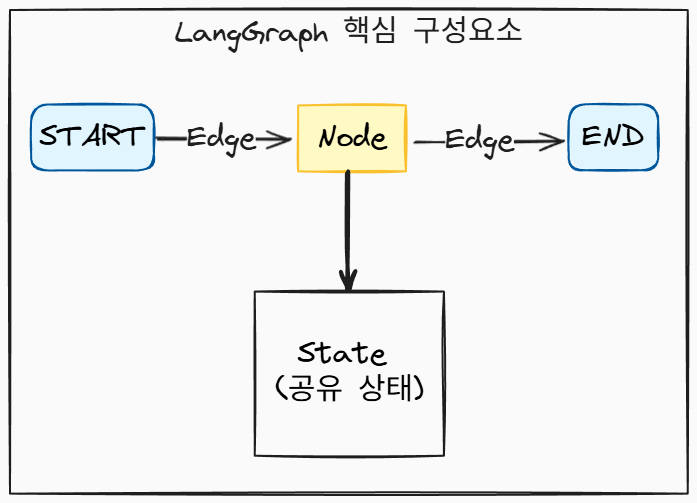

#### 핵심 개념 4가지

| 개념 | 설명 | 역할 |
|------|------|------|
| **State** | 그래프 전체에서 공유되는 데이터 | 노드 간 정보 전달 |
| **Node** | 실제 작업을 수행하는 함수 | LLM 호출, 데이터 처리 |
| **Edge** | 노드 간 연결 (실행 흐름) | 순서 결정, 분기 처리 |
| **Memory** | 호출 간 상태 유지 | 대화 히스토리 저장 |

### 1. State (상태) 정의

State는 **TypedDict**를 사용하여 그래프 전체에서 공유되는 데이터 구조를 정의합니다.

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 기본 State 정의
class SimpleState(TypedDict):
    message: str  # 단일 값

print("- SimpleState: 단일 메시지 저장")

- SimpleState: 단일 메시지 저장


#### Reducer란?

`Annotated[List[str], operator.add]`에서 `operator.add`가 **Reducer** 역할을 합니다.

```python
# Reducer 없이 (덮어쓰기)
state["messages"] = ["새 메시지"]  # 기존 값 사라짐

# Reducer 사용 (누적)
state["messages"] = ["새 메시지"]  # 기존 값 + 새 메시지
# 결과: ["기존1", "기존2", "새 메시지"]
```

In [3]:
import operator
from typing import TypedDict, Annotated, List

# Reducer를 사용한 State 정의 (값 누적)
class AccumulatorState(TypedDict):
    messages: Annotated[List[str], operator.add]  # 리스트에 값 추가

print("- AccumulatorState: 메시지 리스트 누적 (Reducer 사용)")

- AccumulatorState: 메시지 리스트 누적 (Reducer 사용)


### 2. Node (노드) 정의

Node는 **State를 입력받아 업데이트된 State를 반환**하는 Python 함수입니다.

In [ ]:
# 노드 함수 정의
def node_a(state: AccumulatorState) -> AccumulatorState:
    """노드 A: 상태에 'A' 추가"""
    print(f"  [Node A] 현재 상태: {state['messages']}")
    return {"messages": ["A 처리완료"]}

def node_b(state: AccumulatorState) -> AccumulatorState:
    """노드 B: 상태에 'B' 추가"""
    print(f"  [Node B] 현재 상태: {state['messages']}")
    return {"messages": ["B 처리완료"]}

def node_c(state: AccumulatorState) -> AccumulatorState:
    """노드 C: 상태에 'C' 추가"""
    print(f"  [Node C] 현재 상태: {state['messages']}")
    return {"messages": ["C 처리완료"]}

print("✅ 노드 함수 정의 완료")

✅ 노드 함수 정의 완료


### 3. Graph 구성 및 실행

StateGraph를 사용하여 노드를 연결하고 그래프를 실행합니다.

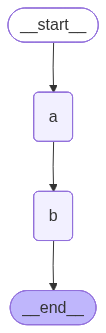

In [ ]:
import nest_asyncio
nest_asyncio.apply() # mermaid 랜더링을 위해 중첩 이벤트 루프 허용

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

# 1. 그래프 빌더 생성
builder = StateGraph(AccumulatorState)

# 2. 노드 추가
builder.add_node("a", node_a)
builder.add_node("b", node_b)

# 3. 엣지 추가 (실행 순서 정의)
builder.add_edge(START, "a")  # 시작 → A
builder.add_edge("a", "b")     # A → B
builder.add_edge("b", END)     # B → 종료

# 4. 그래프 컴파일
graph = builder.compile()

# 5. 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))
# print("\n✅ 순차 실행 그래프 (START → A → B → END)")

In [ ]:
# 그래프 실행
initial_state = {"messages": ["시작"]}
print("🚀 그래프 실행 시작\n")

result = graph.invoke(initial_state)

print(f"\n📊 최종 결과: {result['messages']}")

🚀 그래프 실행 시작

  [Node A] 현재 상태: ['시작']
  [Node B] 현재 상태: ['시작', 'A 처리완료']

📊 최종 결과: ['시작', 'A 처리완료', 'B 처리완료']


### 4. 병렬 실행 (Parallel Execution)

한 노드에서 **여러 개의 outgoing edge**가 있으면 병렬로 실행됩니다.

노드 A에서 B와 C로 동시에 분기하고, D에서 다시 합쳐집니다.

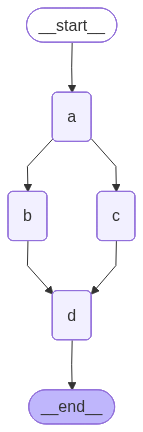


✅ 병렬 실행 그래프 (A에서 B,C로 분기 → D에서 합류)


In [ ]:
# 병렬 실행 그래프 구성
def node_d(state: AccumulatorState) -> AccumulatorState:
    """노드 D: 병합 노드"""
    print(f"  [Node D] 현재 상태: {state['messages']}")
    return {"messages": ["D 병합완료"]}

# 새 그래프 빌더
parallel_builder = StateGraph(AccumulatorState)

# 노드 추가
parallel_builder.add_node("a", node_a)
parallel_builder.add_node("b", node_b)
parallel_builder.add_node("c", node_c)
parallel_builder.add_node("d", node_d)

# 엣지 추가 (병렬 분기)
parallel_builder.add_edge(START, "a")
parallel_builder.add_edge("a", "b")  # A → B (분기 1)
parallel_builder.add_edge("a", "c")  # A → C (분기 2)
parallel_builder.add_edge("b", "d")  # B → D (합류)
parallel_builder.add_edge("c", "d")  # C → D (합류)
parallel_builder.add_edge("d", END)

# 컴파일 및 시각화
parallel_graph = parallel_builder.compile()
display(Image(parallel_graph.get_graph().draw_mermaid_png()))
# print(graph.get_graph().draw_mermaid())
print("\n✅ 병렬 실행 그래프 (A에서 B,C로 분기 → D에서 합류)")

In [ ]:
# 병렬 그래프 실행
print("🚀 병렬 그래프 실행 시작\n")
parallel_result = parallel_graph.invoke({"messages": ["시작"]})

print(f"\n📊 최종 결과: {parallel_result['messages']}")
print("\n💡 B와 C가 동시에 실행되고, Reducer가 결과를 병합합니다!")

🚀 병렬 그래프 실행 시작

  [Node A] 현재 상태: ['시작']
  [Node B] 현재 상태: ['시작', 'A 처리완료']
  [Node C] 현재 상태: ['시작', 'A 처리완료']
  [Node D] 현재 상태: ['시작', 'A 처리완료', 'B 처리완료', 'C 처리완료']

📊 최종 결과: ['시작', 'A 처리완료', 'B 처리완료', 'C 처리완료', 'D 병합완료']

💡 B와 C가 동시에 실행되고, Reducer가 결과를 병합합니다!


- 동작 방식

    `A 실행 → B, C 동시 실행 (parallel) → Reducer가 결과 병합 → D 실행`

### 5. 조건부 엣지 (Conditional Edges)

`add_conditional_edges()`를 사용하면 **상태에 따라 동적으로 경로를 결정**할 수 있습니다.

라우팅 함수가 상태를 보고 어느 노드로 갈지 결정합니다.

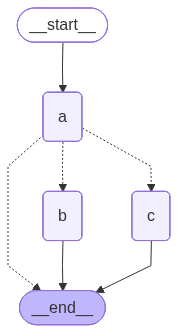

In [ ]:
from typing import Literal

# 라우팅에 사용할 State 정의
class RouterState(TypedDict):
    messages: Annotated[List[str], operator.add]
    route: str  # 라우팅 결정 값

# 라우팅 함수 정의
def routing_function(state: RouterState) -> Literal["b", "c", END]:
    """상태의 route 값에 따라 다음 노드 결정"""
    route = state.get("route", "b")
    print(f"  [Router] route={route} → {route} 노드로 이동")
    if route == "b":
        return "b"
    elif route == "c":
        return "c"
    else:
        return END

# 조건부 그래프 빌더
cond_builder = StateGraph(RouterState)
cond_builder.add_node("a", lambda s: {"messages": ["A"], "route": s["route"]})
cond_builder.add_node("b", lambda s: {"messages": ["B (route=b)"]})
cond_builder.add_node("c", lambda s: {"messages": ["C (route=c)"]})

# 엣지 설정
cond_builder.add_edge(START, "a")
cond_builder.add_conditional_edges("a", routing_function)  # 조건부 엣지!
cond_builder.add_edge("b", END)
cond_builder.add_edge("c", END)

cond_graph = cond_builder.compile()
display(Image(cond_graph.get_graph().draw_mermaid_png()))

In [ ]:
# 테스트
print("\n🔀 조건부 라우팅 테스트:")
print("\n[route='b' 테스트]")
result_b = cond_graph.invoke({"messages": ["시작"], "route": "b"})
print(f"결과: {result_b['messages']}")

print("\n[route='c' 테스트]")
result_c = cond_graph.invoke({"messages": ["시작"], "route": "c"})
print(f"결과: {result_c['messages']}")


🔀 조건부 라우팅 테스트:

[route='b' 테스트]
  [Router] route=b → b 노드로 이동
결과: ['시작', 'A', 'B (route=b)']

[route='c' 테스트]
  [Router] route=c → c 노드로 이동
결과: ['시작', 'A', 'C (route=c)']


### 6. Memory (Checkpointer)

`MemorySaver`를 사용하면 **그래프 호출 간 상태를 유지**할 수 있습니다.

| 호출 |        Memory (Checkpointer)       |
|:---:|:--------------------------------------------:|
|호출 1 (thread_id="user1")|state: {messages: ["안녕"]} ──────────────▶ 저장 |
|호출 2 (thread_id="user1")|state: {messages: ["안녕", "반가워"]} ◀──── 복원 + 추가|

**thread_id**를 사용하여 서로 다른 대화 세션을 구분합니다.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# Memory 전용 State 정의
class MemoryState(TypedDict):
    messages: Annotated[List[str], operator.add]

# Memory 전용 노드
def mem_node_a(state: MemoryState) -> MemoryState:
    print(f"  [Node A] 현재 상태: {state['messages']}")
    return {"messages": ["A 처리완료"]}

def mem_node_b(state: MemoryState) -> MemoryState:
    print(f"  [Node B] 현재 상태: {state['messages']}")
    return {"messages": ["B 처리완료"]}

# Memory 전용 그래프 빌더 (새로 생성)
mem_builder = StateGraph(MemoryState)
mem_builder.add_node("a", mem_node_a)
mem_builder.add_node("b", mem_node_b)
mem_builder.add_edge(START, "a")
mem_builder.add_edge("a", "b")
mem_builder.add_edge("b", END)

# Memory(Checkpointer) 적용하여 컴파일
memory = MemorySaver()
memory_graph = mem_builder.compile(checkpointer=memory)

# 첫 번째 호출 (thread_id="conversation1")
config = {"configurable": {"thread_id": "conversation1"}}
print("📝 첫 번째 호출 (thread_id='conversation1')")
result1 = memory_graph.invoke({"messages": ["첫 번째 메시지"]}, config)
print(f"결과: {result1['messages']}")

📝 첫 번째 호출 (thread_id='conversation1')
  [Node A] 현재 상태: ['첫 번째 메시지']
  [Node B] 현재 상태: ['첫 번째 메시지', 'A 처리완료']
결과: ['첫 번째 메시지', 'A 처리완료', 'B 처리완료']


In [ ]:
# 두 번째 호출 (같은 thread_id - 이전 상태 유지)
print("\n📝 두 번째 호출 (같은 thread_id - 상태 유지)")
result2 = memory_graph.invoke({"messages": ["두 번째 메시지"]}, config)
print(f"결과: {result2['messages']}")


📝 두 번째 호출 (같은 thread_id - 상태 유지)
  [Node A] 현재 상태: ['첫 번째 메시지', 'A 처리완료', 'B 처리완료', '두 번째 메시지']
  [Node B] 현재 상태: ['첫 번째 메시지', 'A 처리완료', 'B 처리완료', '두 번째 메시지', 'A 처리완료']
결과: ['첫 번째 메시지', 'A 처리완료', 'B 처리완료', '두 번째 메시지', 'A 처리완료', 'B 처리완료']


In [ ]:
# 다른 thread_id로 호출 (새로운 대화)
config2 = {"configurable": {"thread_id": "conversation2"}}
print("\n📝 세 번째 호출 (thread_id='conversation2' - 새 대화)")
result3 = memory_graph.invoke({"messages": ["새 대화 시작"]}, config2)
print(f"결과: {result3['messages']}")

print("\n💡 같은 thread_id는 상태를 유지하고, 다른 thread_id는 새로운 대화!")


📝 세 번째 호출 (thread_id='conversation2' - 새 대화)
  [Node A] 현재 상태: ['새 대화 시작']
  [Node B] 현재 상태: ['새 대화 시작', 'A 처리완료']
결과: ['새 대화 시작', 'A 처리완료', 'B 처리완료']

💡 같은 thread_id는 상태를 유지하고, 다른 thread_id는 새로운 대화!


### 7. Human-In-The-Loop (HITL)

LangGraph의 `interrupt()` 함수를 사용하면 **그래프 실행을 일시 정지하고 사람의 입력을 기다릴 수 있습니다**.

이를 통해 다음과 같은 시나리오를 처리할 수 있습니다:
- 예상치 못한 입력에 대한 관리자 검토
- 중요한 결정 전 사람의 승인
- 에러 발생 시 수동 개입

**중요**: `interrupt()`를 사용하려면 반드시 **Checkpointer**가 필요합니다!

In [ ]:
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import MemorySaver

# HITL용 State 정의
class HITLState(TypedDict):
    messages: Annotated[List[str], operator.add]

# HITL용 Memory 설정
hitl_memory = MemorySaver()

# 노드 정의: interrupt() 사용
def hitl_node_a(state: HITLState) -> Command[Literal["b", "c", END]]:
    """노드 A: 입력값에 따라 분기하거나 interrupt 발생"""
    print(f"  [Node A] 현재 상태: {state['messages']}")

    user_input = state["messages"][-1]

    if user_input == "b":
        next_node = "b"
    elif user_input == "c":
        next_node = "c"
    elif user_input == "q":
        next_node = END
    else:
        # 예상치 못한 입력 → interrupt 발생!
        admin_response = interrupt(f"⚠️ 예상치 못한 입력: '{user_input}' - 어떻게 처리할까요?")
        print(f"  [Admin 응답] {admin_response}")

        if admin_response == "continue":
            next_node = "b"  # 기본 경로로 진행
        else:
            next_node = END
            user_input = "q"

    return Command(
        update={"messages": [f"A→{next_node}"]},
        goto=next_node
    )

def hitl_node_b(state: HITLState) -> HITLState:
    """노드 B 처리"""
    print(f"  [Node B] 현재 상태: {state['messages']}")
    return {"messages": ["B 처리완료"]}

def hitl_node_c(state: HITLState) -> HITLState:
    """노드 C 처리"""
    print(f"  [Node C] 현재 상태: {state['messages']}")
    return {"messages": ["C 처리완료"]}

print("✅ HITL 노드 정의 완료")
print("- hitl_node_a: interrupt() 사용하여 예외 상황에서 사람 입력 대기")
print("- hitl_node_b, hitl_node_c: 일반 처리 노드")

✅ HITL 노드 정의 완료
- hitl_node_a: interrupt() 사용하여 예외 상황에서 사람 입력 대기
- hitl_node_b, hitl_node_c: 일반 처리 노드


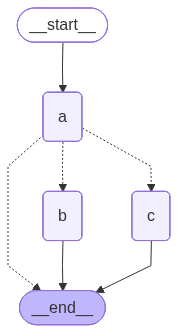


✅ HITL 그래프 구성 완료
💡 node_a에서 Command를 사용하여 상태 업데이트와 라우팅을 동시에 처리


In [ ]:
# HITL 그래프 구성
hitl_builder = StateGraph(HITLState)

# 노드 추가
hitl_builder.add_node("a", hitl_node_a)
hitl_builder.add_node("b", hitl_node_b)
hitl_builder.add_node("c", hitl_node_c)

# 엣지 추가 (node_a는 Command로 직접 라우팅하므로 별도 엣지 불필요)
hitl_builder.add_edge(START, "a")
hitl_builder.add_edge("b", END)
hitl_builder.add_edge("c", END)

# 컴파일 (checkpointer 필수!)
hitl_graph = hitl_builder.compile(checkpointer=hitl_memory)

# 시각화
display(Image(hitl_graph.get_graph().draw_mermaid_png()))
print("\n✅ HITL 그래프 구성 완료")
print("💡 node_a에서 Command를 사용하여 상태 업데이트와 라우팅을 동시에 처리")

#### HITL 실행 테스트

직접 입력하면서 테스트해봅니다.
- `b` 입력 → Node B로 이동
- `c` 입력 → Node C로 이동  
- `q` 입력 → 종료
- **그 외 입력** → interrupt 발생 → 관리자 응답 대기

In [ ]:
# 대화형 HITL 테스트
hitl_config_interactive = {"configurable": {"thread_id": "hitl_interactive"}}

print("🎮 HITL 대화형 테스트")
print("=" * 50)
print("사용법: b(→B노드), c(→C노드), q(종료), 그 외(→interrupt)")
print("=" * 50)

while True:
    user_input = input("\n입력 (b/c/q/기타): ")

    # 그래프 실행
    result = hitl_graph.invoke({"messages": [user_input]}, hitl_config_interactive)

    # interrupt 발생 확인 및 처리
    if "__interrupt__" in result:
        print(f"\n🛑 Interrupt 발생!")
        interrupt_msg = result["__interrupt__"][-1].value
        print(f"메시지: {interrupt_msg}")

        # 관리자 응답 받기
        admin_input = input("\n👤 관리자 응답 (continue=계속/quit=종료): ")

        # 그래프 재개
        result = hitl_graph.invoke(Command(resume=admin_input), hitl_config_interactive)
        print(f"\n✅ 그래프 재개됨!")

    print(f"📊 결과: {result['messages']}")

    # 종료 조건 확인
    if user_input == "q" or (result["messages"] and "→__end__" in str(result["messages"][-1])):
        print("\n👋 테스트 종료!")
        break

🎮 HITL 대화형 테스트
사용법: b(→B노드), c(→C노드), q(종료), 그 외(→interrupt)

입력 (b/c/q/기타): b
  [Node A] 현재 상태: ['b']
  [Node B] 현재 상태: ['b', 'A→b']
📊 결과: ['b', 'A→b', 'B 처리완료']

입력 (b/c/q/기타): hi
  [Node A] 현재 상태: ['b', 'A→b', 'B 처리완료', 'hi']

🛑 Interrupt 발생!
메시지: ⚠️ 예상치 못한 입력: 'hi' - 어떻게 처리할까요?

👤 관리자 응답 (continue=계속/quit=종료): continue
  [Node A] 현재 상태: ['b', 'A→b', 'B 처리완료', 'hi']
  [Admin 응답] continue
  [Node B] 현재 상태: ['b', 'A→b', 'B 처리완료', 'hi', 'A→b']

✅ 그래프 재개됨!
📊 결과: ['b', 'A→b', 'B 처리완료', 'hi', 'A→b', 'B 처리완료']

입력 (b/c/q/기타): hi
  [Node A] 현재 상태: ['b', 'A→b', 'B 처리완료', 'hi', 'A→b', 'B 처리완료', 'hi']

🛑 Interrupt 발생!
메시지: ⚠️ 예상치 못한 입력: 'hi' - 어떻게 처리할까요?

👤 관리자 응답 (continue=계속/quit=종료): quit
  [Node A] 현재 상태: ['b', 'A→b', 'B 처리완료', 'hi', 'A→b', 'B 처리완료', 'hi']
  [Admin 응답] quit

✅ 그래프 재개됨!
📊 결과: ['b', 'A→b', 'B 처리완료', 'hi', 'A→b', 'B 처리완료', 'hi', 'A→__end__']

👋 테스트 종료!


#### interrupt()와 Command 이해하기

| 개념 | 코드 | 설명 |
|------|------|------|
| **interrupt()** | `interrupt("메시지")` | 그래프 실행을 일시 정지하고 사람 입력 대기 |
| **Command (update)** | `Command(update={...})` | 상태 업데이트 |
| **Command (goto)** | `Command(goto="node")` | 다음 노드 지정 (동적 라우팅) |
| **Command (resume)** | `Command(resume="값")` | 일시 정지된 그래프 재개 |

```python
# interrupt 발생
admin_response = interrupt("예외 상황 발생!")
# → 그래프 일시 정지, admin_response는 재개 시 받은 값

# 그래프 재개
result = graph.invoke(Command(resume="continue"), config)
# → interrupt() 함수가 "continue" 값을 반환하며 재개
```

### LangGraph Essentials 정리

| 개념 | 코드 | 설명 |
|------|------|------|
| **State** | `class MyState(TypedDict)` | 그래프 전체 공유 데이터 |
| **Reducer** | `Annotated[List, operator.add]` | 값 누적 (덮어쓰기 방지) |
| **Node** | `def my_node(state) -> state` | 상태를 받아 처리하는 함수 |
| **Edge** | `add_edge("a", "b")` | 노드 간 연결 (순서 정의) |
| **Parallel** | 한 노드에서 여러 Edge | 동시 실행 후 병합 |
| **Conditional** | `add_conditional_edges()` | 상태 기반 동적 라우팅 |
| **Memory** | `compile(checkpointer=memory)` | 호출 간 상태 유지 |
| **HITL** | `interrupt()` + `Command(resume=)` | 사람 입력 대기 후 재개 |

**핵심 패턴**: `State 정의` → `Node 작성` → `Edge 연결` → `compile()` → `invoke()`